In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score


In [20]:
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split
from utils.check_multicollinearity import check_multicollinearity 
from utils.calculate_regression_metrics import calculate_regression_metrics

In [21]:
MACRO_COLS = ['CPI_Change', 'Rate_Change', 'GDP_Growth', 'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread']
LAGGED_COLS =[
    'CPI_Change_lag1',
    'GDP_Growth_lag2',
    'Unemp_Change_lag1',
    'Credit_Spread_lag2'
    ]
# remove some features cols and run several times to see how it affects the performance

In [22]:
df = pd.read_csv('../data/processed/processed_data.csv',parse_dates=['Date'])

# df.info()



In [37]:

# MODEL 1: Linear Regression (7 variables, NO lags)

from utils.calculate_regression_metrics import evaluate_model
print("\n" + "="*50)
print("MODEL 1: Linear Regression (7 Variables - Baseline)")
print("="*50)


# Prepare Data without Lags
splits_data = data_split(df,MACRO_COLS)

X_train = splits_data['X_train']
y_train = splits_data['y_train']

X_test  = splits_data['X_test']
y_test  = splits_data['y_test']



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_scaled  = scaler.transform(X_test)


# Train model
model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)


# Evaluate
ev_result1 = evaluate_model(model_1, X_train_scaled, y_train, X_test_scaled, y_test, "Model 1 - Test")


# Print coefficients
coef_df_1 = pd.DataFrame({
    'Feature': MACRO_COLS,
    'Coefficient': model_1.coef_,
    'Abs_Coef': np.abs(model_1.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS:")
print(coef_df_1.to_string(index=False))


MODEL 1: Linear Regression (7 Variables - Baseline)

  Train       n= 346  1991-03-01 to 2019-12-01  μ=0.63%  σ=4.08%

  Test        n=  69  2020-01-01 to 2025-09-01  μ=1.05%  σ=5.02%

  Features (7): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread

  Model 1 - Test
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3766     0.0751
  RMSE (%)                       3.222      4.826
  MAE (%)                        2.434      3.545
  Directional Acc (%)            75.43      73.91

COEFFICIENTS:
      Feature  Coefficient  Abs_Coef
   VIX_Change    -2.381333  2.381333
Credit_Spread    -0.792480  0.792480
   USD_Change    -0.545496  0.545496
 Unemp_Change    -0.291311  0.291311
   CPI_Change    -0.225185  0.225185
  Rate_Change    -0.206304  0.206304
   GDP_Growth    -0.079954  0.079954


In [ ]:

# MODEL 2: Linear Regression With Combining lags
FEATURE_COLS = ['CPI_Change_lag1', 'Rate_Change', 'GDP_Growth_lag2', 'Unemp_Change_lag1', 'USD_Change', 'VIX_Change', 'Credit_Spread_lag2']


print("\n" + "="*50)
print("MODEL 2: Linear Regression with combining lags")
print("="*50)

splits_data_2 = data_split(df,FEATURE_COLS)

X_train_mixed_lagged = splits_data_2['X_train']
y_train_mixed_lagged = splits_data_2['y_train']

X_test_mixed_lagged  = splits_data_2['X_test']
y_test_mixed_lagged  = splits_data_2['y_test']

scaler         = StandardScaler()
X_train_scaled_2 = scaler.fit_transform(X_train_mixed_lagged)   # fit + transform on TRAIN only
X_test_scaled_2  = scaler.transform(X_test_mixed_lagged)

# Train model
model_2 = LinearRegression()
model_2.fit(X_train_scaled_2, y_train_mixed_lagged)

# Evaluate
ev_result2 = evaluate_model(model_2, X_train_scaled_2, y_train_mixed_lagged, X_test_scaled_2, y_test_mixed_lagged, "Model 2 - Test")






MODEL 2: Linear Regression with combining lags

  Train       n= 346  1991-03-01 to 2019-12-01  μ=0.63%  σ=4.08%

  Test        n=  69  2020-01-01 to 2025-09-01  μ=1.05%  σ=5.02%

  Features (7): CPI_Change_lag1, Rate_Change, GDP_Growth_lag2, Unemp_Change_lag1, USD_Change, VIX_Change, Credit_Spread_lag2

  Model 2 - Test
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3739     0.0853
  RMSE (%)                       3.229      4.800
  MAE (%)                        2.458      3.527
  Directional Acc (%)            73.99      69.57


In [39]:

# MODEL 3: Linear Regression With lags

print("\n" + "="*50)
print("MODEL 3: Linear Regression with lags")
print("="*50)

splits_data_3 = data_split(df,MACRO_COLS + LAGGED_COLS)

X_train_lagged = splits_data_3['X_train']
y_train_lagged = splits_data_3['y_train']

X_test_lagged  = splits_data_3['X_test']
y_test_lagged  = splits_data_3['y_test']

scaler         = StandardScaler()
X_train_scaled_3 = scaler.fit_transform(X_train_lagged)   # fit + transform on TRAIN only
X_test_scaled_3  = scaler.transform(X_test_lagged)

# Train model
model_3 = LinearRegression()
model_3.fit(X_train_scaled_3, y_train_lagged)


# Evaluate
ev_result3 = evaluate_model(model_3, X_train_scaled_3, y_train_lagged, X_test_scaled_3, y_test_lagged, "Model 3 - Test")


# Print coefficients
coef_df_3 = pd.DataFrame({
    'Feature': MACRO_COLS + LAGGED_COLS,
    'Coefficient': model_3.coef_,
    'Abs_Coef': np.abs(model_3.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS:")





MODEL 3: Linear Regression with lags

  Train       n= 346  1991-03-01 to 2019-12-01  μ=0.63%  σ=4.08%

  Test        n=  69  2020-01-01 to 2025-09-01  μ=1.05%  σ=5.02%

  Features (11): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread, CPI_Change_lag1, GDP_Growth_lag2, Unemp_Change_lag1, Credit_Spread_lag2

  Model 3 - Test
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3901    -0.3961
  RMSE (%)                       3.187      5.930
  MAE (%)                        2.409      4.286
  Directional Acc (%)            74.86      65.22

COEFFICIENTS:


In [40]:
print(coef_df_3.to_string(index=False))

           Feature  Coefficient  Abs_Coef
        VIX_Change    -2.396863  2.396863
   GDP_Growth_lag2    -1.098706  1.098706
        GDP_Growth     1.021864  1.021864
     Credit_Spread    -0.606216  0.606216
        USD_Change    -0.537686  0.537686
 Unemp_Change_lag1    -0.317521  0.317521
        CPI_Change    -0.296629  0.296629
      Unemp_Change    -0.289599  0.289599
       Rate_Change    -0.284578  0.284578
   CPI_Change_lag1     0.243983  0.243983
Credit_Spread_lag2     0.046373  0.046373


In [41]:
# Check for multicollinearity

X_train_lagged_df = pd.DataFrame(X_train_lagged, columns=MACRO_COLS + LAGGED_COLS)
print("\nMULTICOLLINEARITY CHECK (VIF):")
vif_results = check_multicollinearity(X_train_lagged_df, threshold=5.0)


MULTICOLLINEARITY CHECK (VIF):

Variance Inflation Factor (VIF):
           Feature       VIF Concern
   GDP_Growth_lag2 89.635238    High
        GDP_Growth 89.230883    High
     Credit_Spread 52.412648    High
Credit_Spread_lag2 50.373382    High
        CPI_Change  2.232127      OK
   CPI_Change_lag1  1.977570      OK
 Unemp_Change_lag1  1.295880      OK
      Unemp_Change  1.261845      OK
       Rate_Change  1.242026      OK
        VIX_Change  1.106060      OK
        USD_Change  1.088589      OK

Note: VIF > 5.0 indicates multicollinearity concern


In [42]:
alphas = np.logspace(-3, 5, 100)

# Manually compute CV score for each alpha
cv_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(
        ridge, 
        X_train_lagged, 
        y_train_lagged, 
        cv=5, 
        scoring='r2'
    )
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

# Find best alpha manually
best_alpha = alphas[np.argmax(cv_scores)]
print(f"Best alpha: {best_alpha:.4f}")

Best alpha: 178.8650


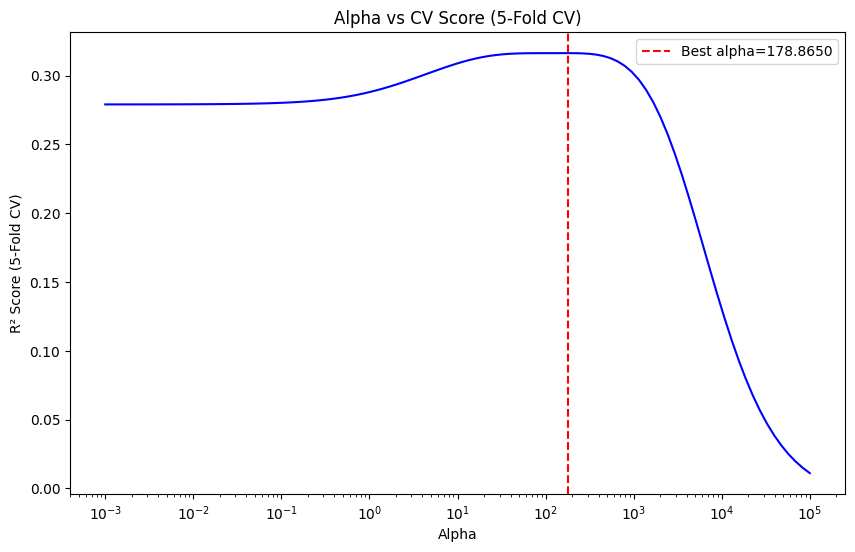

In [43]:
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, cv_scores, color='blue')
plt.axvline(best_alpha, color='red', linestyle='--',
            label=f'Best alpha={best_alpha:.4f}')
plt.xlabel('Alpha')
plt.ylabel('R² Score (5-Fold CV)')
plt.title('Alpha vs CV Score (5-Fold CV)')
plt.legend()
plt.show()

In [44]:

# Train final Ridge model with best alpha
# MODEL 4: Ridge Regression

print("\n" + "="*50)
print("MODEL 4: Ridge Regression")
print("="*50)

model_4 = Ridge(alpha=best_alpha)
model_4.fit(X_train_lagged, y_train_lagged)

# Predict
y_train_pred_4 = model_4.predict(X_train_lagged)
y_test_pred_4 = model_4.predict(X_test_lagged)

# Evaluate
ev_result4 = evaluate_model(model_4, X_train_lagged, y_train_lagged, X_test_lagged, y_test_lagged, "Model 4 - Test")

# Print coefficients (on scaled features)
coef_df_4 = pd.DataFrame({
    'Feature': MACRO_COLS + LAGGED_COLS,
    'Coefficient': model_4.coef_,
    'Abs_Coef': np.abs(model_4.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS (on standardized scale):")
print(coef_df_4.to_string(index=False))


MODEL 4: Ridge Regression

  Model 4 - Test
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3614     0.2996
  RMSE (%)                       3.262      4.200
  MAE (%)                        2.463      3.192
  Directional Acc (%)            73.70      72.46

COEFFICIENTS (on standardized scale):
           Feature  Coefficient  Abs_Coef
        VIX_Change    -0.625514  0.625514
        GDP_Growth     0.267520  0.267520
     Credit_Spread    -0.244340  0.244340
        USD_Change    -0.243865  0.243865
Credit_Spread_lag2    -0.187977  0.187977
   CPI_Change_lag1     0.152076  0.152076
   GDP_Growth_lag2    -0.112609  0.112609
      Unemp_Change    -0.087879  0.087879
 Unemp_Change_lag1    -0.086825  0.086825
        CPI_Change    -0.083056  0.083056
       Rate_Change    -0.041352  0.041352


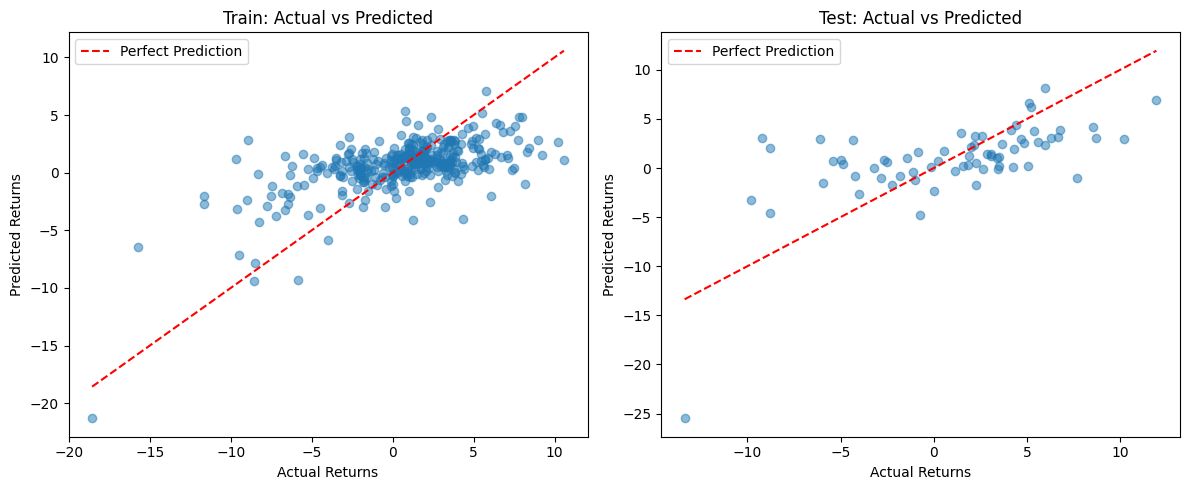

In [31]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1, 2, 1)
plt.scatter(y_train_lagged, y_train_pred_4, alpha=0.5)
plt.plot([y_train_lagged.min(), y_train_lagged.max()],
         [y_train_lagged.min(), y_train_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Train: Actual vs Predicted')
plt.legend()

# Test
plt.subplot(1, 2, 2)
plt.scatter(y_test_lagged, y_test_pred_4, alpha=0.5)
plt.plot([y_test_lagged.min(), y_test_lagged.max()],
         [y_test_lagged.min(), y_test_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Test: Actual vs Predicted')
plt.legend()

plt.tight_layout()
plt.show()

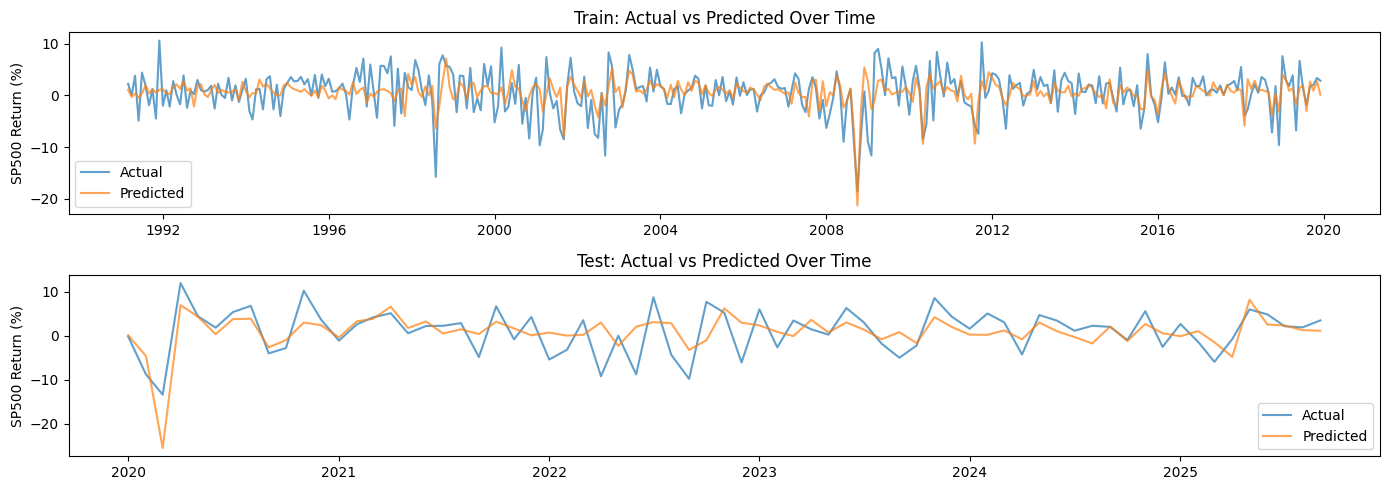

In [32]:
plt.figure(figsize=(14, 5))

dates_train,dates_test = splits_data['dates_train'], splits_data['dates_test']  
# Train
plt.subplot(2, 1, 1)
plt.plot(dates_train, y_train_lagged, label='Actual', alpha=0.7)
plt.plot(dates_train, y_train_pred_4,  label='Predicted', alpha=0.7)
plt.title('Train: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

# Test
plt.subplot(2, 1, 2)
plt.plot(dates_test, y_test_lagged, label='Actual', alpha=0.7)
plt.plot(dates_test, y_test_pred_4,  label='Predicted', alpha=0.7)
plt.title('Test: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

plt.tight_layout()
plt.show()

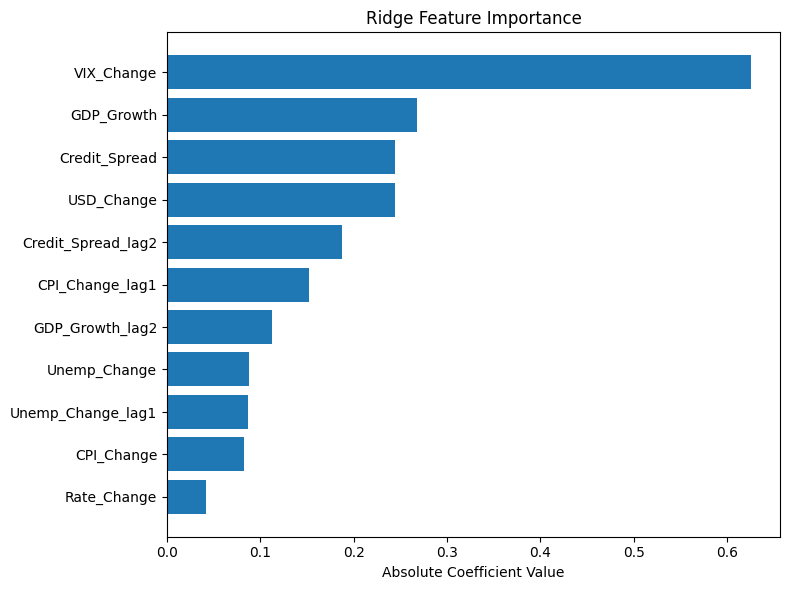

In [33]:
coef_df = pd.DataFrame({
    'Feature'    : MACRO_COLS + LAGGED_COLS,
    'Coefficient': np.abs(model_4.coef_)
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Ridge Feature Importance')
plt.tight_layout()
plt.show()

In [34]:
import pickle

# Save the fitted ridge model
with open('ridge_model.pkl', 'wb') as f:
    pickle.dump(model_4, f)

print("  Ridge model saved → ridge_model.pkl")

  Ridge model saved → ridge_model.pkl
